In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv(
    "results/volatility_predictions.csv",
    index_col=0,
    parse_dates=True
)

df.head()

,actual_vol,predicted_vol
date,,
2025-01-22 10:54:00,0.000170,0.000340
2025-01-22 10:55:00,0.000294,0.000323
2025-01-22 10:56:00,0.000308,0.000292
2025-01-22 10:57:00,0.000298,0.000305
2025-01-22 10:58:00,0.000297,0.000295


In [19]:
df["volatility_regime"] = pd.qcut(
    df["actual_vol"],
    q=3,
    labels=[
        "Low Vol",
        "Medium Vol",
        "High Vol"
    ]
)

df["volatility_regime"].value_counts()

volatility_regime
Low Vol       15837
Medium Vol    15837
High Vol      15837
Name: count, dtype: int64

In [20]:
regime_results = []

for regime in df["volatility_regime"].unique():

    temp = df[
        df["volatility_regime"] == regime
    ]

    correlation = temp[
        "actual_vol"
    ].corr(
        temp[
            "predicted_vol"
        ]
    )

    mae = np.mean(
        np.abs(
            temp["actual_vol"]
            -
            temp["predicted_vol"]
        )
    )

    rmse = np.sqrt(
        np.mean(
            (
                temp["actual_vol"]
                -
                temp["predicted_vol"]
            ) ** 2
        )
    )

    regime_results.append(
        [
            regime,
            len(temp),
            correlation,
            mae,
            rmse
        ]
    )

regime_table = pd.DataFrame(
    regime_results,
    columns=[
        "Regime",
        "Samples",
        "Correlation",
        "MAE",
        "RMSE"
    ]
)

regime_table

,Regime,Samples,Correlation,MAE,RMSE
0,Low Vol,15837,0.321195,0.000061,0.000076
1,Medium Vol,15837,0.283374,0.000056,0.000082
2,High Vol,15837,0.449297,0.000174,0.000432


In [21]:
comparison = (
    df.groupby(
        "volatility_regime"
    )[
        [
            "actual_vol",
            "predicted_vol"
        ]
    ]
    .mean()
)

comparison

,actual_vol,predicted_vol
volatility_regime,,
Low Vol,0.000137,0.000198
Medium Vol,0.000241,0.000258
High Vol,0.000525,0.000416


In [22]:
df["forecast_error"] = (
    df["predicted_vol"]
    -
    df["actual_vol"]
)

bias_table = (
    df.groupby(
        "volatility_regime"
    )[
        "forecast_error"
    ]
    .mean()
)

bias_table

volatility_regime
Low Vol       0.000060
Medium Vol    0.000017
High Vol     -0.000109
Name: forecast_error, dtype: float64

<Figure size 1000x500 with 0 Axes>

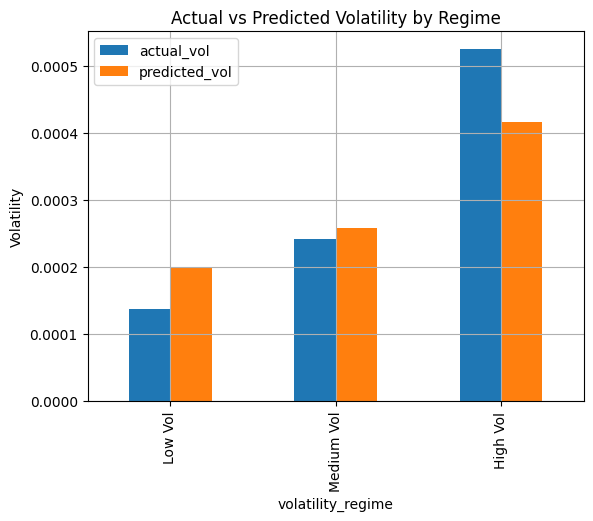

In [23]:
plt.figure(figsize=(10,5))

comparison.plot(
    kind="bar"
)

plt.title(
    "Actual vs Predicted Volatility by Regime"
)

plt.ylabel(
    "Volatility"
)

plt.grid(True)

plt.savefig(
    "plots/Actual vs Predicted Volatility by Regime.png",
    bbox_inches="tight"
)

plt.show()

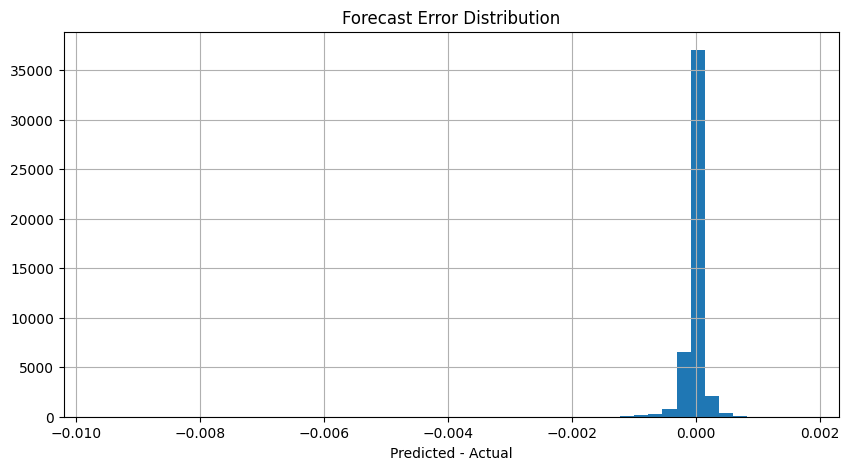

In [24]:
plt.figure(figsize=(10,5))

df[
    "forecast_error"
].hist(
    bins=50
)

plt.title(
    "Forecast Error Distribution"
)

plt.xlabel(
    "Predicted - Actual"
)

plt.grid(True)

plt.savefig(
    "plots/forecast_errorpng.png",
    bbox_inches="tight"
)

plt.show()

In [25]:
df["pred_bucket"] = pd.qcut(
    df["predicted_vol"],
    q=5,
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

calibration = (
    df.groupby(
        "pred_bucket"
    )[
        [
            "actual_vol",
            "predicted_vol"
        ]
    ]
    .mean()
)

calibration

,actual_vol,predicted_vol
pred_bucket,,
Very Low,0.000161,0.000168
Low,0.000201,0.000195
Medium,0.000245,0.000243
High,0.000315,0.000314
Very High,0.000584,0.000534


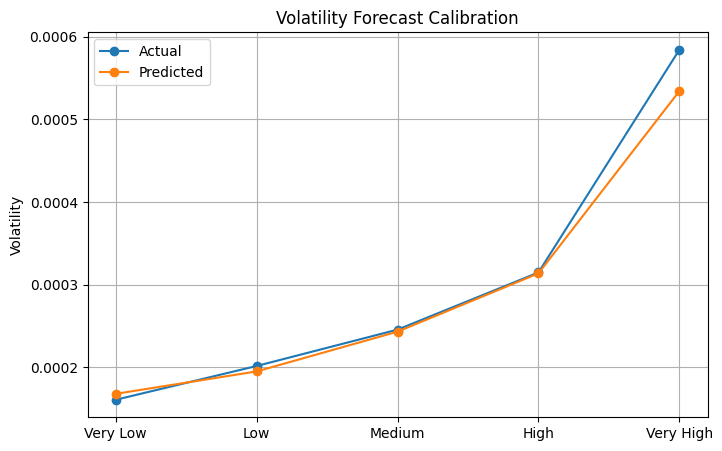

In [26]:
plt.figure(figsize=(8,5))

plt.plot(
    calibration.index,
    calibration["actual_vol"],
    marker="o",
    label="Actual"
)

plt.plot(
    calibration.index,
    calibration["predicted_vol"],
    marker="o",
    label="Predicted"
)

plt.title(
    "Volatility Forecast Calibration"
)

plt.ylabel(
    "Volatility"
)

plt.legend()

plt.grid(True)

plt.savefig(
    "plots/forecast_calibration.png",
    bbox_inches="tight"
)

plt.show()

In [27]:
regime_table.to_csv(
    "results/volatility_regime_analysis.csv",
    index=False
)

comparison.to_csv(
    "results/regime_comparison.csv"
)

calibration.to_csv(
    "results/forecast_calibration.csv"
)

print(
    "Results saved successfully."
)

Results saved successfully.
